# Эконометрический анализ цены ЕГЭ-репетиторов на Profi.ru

**Цель:** оценить хедонистическую модель цены, выбрать функциональную форму и набор регрессоров, проверить предпосылки теоремы Гаусса–Маркова и гипотезу о нормальности ошибок, сравнить спецификации и обосновать выбор лучшей модели.

**Данные:** профильный файл `clean_ege_dataset.csv` (1 448 активных репетиторов с отзывом за последние 6 мес.) и файл «длинного» формата `clean_ege_dataset_long.csv` для проверки на устойчивость с фиксированными эффектами по предмету.

**План:**
1. Подготовка данных, выбор регрессоров с учётом результатов EDA.
2. Спецификация пяти моделей (M1–M5) с разной функциональной формой и набором переменных.
3. Оценка моделей по МНК, сравнение по AIC / BIC / Adj. R² / F-статистике.
4. Диагностика лучшей модели: VIF, Breusch–Pagan, White, Jarque–Bera, Ramsey RESET, остатки, Cook's distance.
5. При нарушении гомоскедастичности — пересчёт стандартных ошибок (HC3).
6. Интерпретация коэффициентов и экономический вывод.
7. Проверка устойчивости на длинном файле с фиксированными эффектами и кластерными ошибками.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset, normal_ad
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from scipy import stats

EXPORTS = "outputs/dataset_exports"
ECON_DIR = "outputs/econ"
os.makedirs(ECON_DIR, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (8, 4.5)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

df_full = pd.read_csv(f"{EXPORTS}/clean_ege_dataset.csv")
df_long_full = pd.read_csv(f"{EXPORTS}/clean_ege_dataset_long.csv")
print("исходные размеры — wide:", df_full.shape, " long:", df_long_full.shape)

исходные размеры — wide: (1413, 41)  long: (2092, 47)


## 1. Подготовка данных

**Решения, обоснованные EDA:**
- Зависимая переменная — `log(price_avg)` (асимметрия распределения 1.58 → −0.33 после логарифмирования).
- Удаляем профили без цены (291 профиль, 20.1%) — для них зависимая переменная не определена.
- Исключаем `passport_verified` и `remote_available` (доминирующий класс ≥ 95%, нулевая дисперсия).
- Исключаем `years_on_site` и `price_max` из-за коллинеарности с `experience_years` (ρ=0.76) и `price_avg` (ρ=0.92).
- Скошенные регрессоры (`experience_years`, `reviews_count`, `about_len`) логарифмируем `log1p(·)` (для нулей).
- `rating_avg` оставляем линейно (ограниченная шкала 1–5).

In [2]:
df = df_full.dropna(subset=["price_avg"]).copy()
df = df[df["price_avg"] > 0].copy()

# Заполняем пропуски, чтобы ВСЕ спецификации работали на одной выборке (важно для AIC/BIC сравнения).
df["about_missing"] = df["about_len"].isna().astype(int)
df["about_len"]     = df["about_len"].fillna(0)
df["experience_missing"] = df["experience_years"].isna().astype(int)
df["experience_years"]   = df["experience_years"].fillna(0)

df["log_price"]      = np.log(df["price_avg"])
df["log_exp"]        = np.log1p(df["experience_years"])
df["log_reviews"]    = np.log1p(df["reviews_count"])
df["log_about_len"]  = np.log1p(df["about_len"])
df["log_education"]  = np.log1p(df["education_count"])
df["log_achievements"] = np.log1p(df["achievements_count"])

# Бинарные / категориальные.
df["is_top_university"]      = df["is_top_university"].astype(int)
df["client_visit_available"] = df["client_visit_available"].astype(int)
df["male"] = (df["gender_raw"] == "MALE").astype(int)
df["female"] = (df["gender_raw"] == "FEMALE").astype(int)

# rating_avg имеет пропуски (для тех, у кого нет рейтинга). Заполним медианой и добавим dummy на пропуск.
df["rating_missing"] = df["rating_avg"].isna().astype(int)
df["rating_avg_imp"] = df["rating_avg"].fillna(df["rating_avg"].median())

print(f"итоговая выборка (одна для всех моделей): n = {len(df)}")
print(f"\nраспределение log(price): mean = {df['log_price'].mean():.3f}, std = {df['log_price'].std():.3f}")
print(f"среднее experience_years   = {df['experience_years'].mean():.1f}")
print(f"доля male                  = {df['male'].mean():.1%}")
print(f"доля female                = {df['female'].mean():.1%}")
print(f"доля is_top_university     = {df['is_top_university'].mean():.1%}")
print(f"доля about_missing         = {df['about_missing'].mean():.1%}")
print(f"доля experience_missing    = {df['experience_missing'].mean():.1%}")
print(f"доля rating_missing        = {df['rating_missing'].mean():.1%}")

итоговая выборка (одна для всех моделей): n = 1130

распределение log(price): mean = 7.749, std = 0.389
среднее experience_years   = 8.9
доля male                  = 46.9%
доля female                = 53.1%
доля is_top_university     = 30.2%
доля about_missing         = 0.0%
доля experience_missing    = 10.2%
доля rating_missing        = 0.0%


## 2. Спецификации моделей

Сравниваем пять моделей, идущих от самой простой к более насыщенной:

| Модель | Форма | Идея |
|---|---|---|
| **M1** | линейная | бенчмарк: цена ~ опыт + отзывы + рейтинг (без преобразований) |
| **M2** | log-linear (log price) | стандартный хедонистический подход, проценты |
| **M3** | log–log | эластичности по непрерывным регрессорам |
| **M4** | log–log + бинарные характеристики | добавляем сигналы (топ-вуз, выезд, пол) |
| **M5** | M4 + взаимодействия | проверяем, отличается ли отдача на опыт у выпускников топ-вузов |


In [3]:
specs = {
    "M1 (linear)":
        "price_avg ~ experience_years + reviews_count + rating_avg_imp + rating_missing",
    "M2 (log-linear)":
        "log_price ~ experience_years + reviews_count + rating_avg_imp + rating_missing",
    "M3 (log-log)":
        "log_price ~ log_exp + log_reviews + rating_avg_imp + rating_missing + log_about_len + about_missing",
    "M4 (log-log + dummies)":
        "log_price ~ log_exp + log_reviews + rating_avg_imp + rating_missing + log_about_len + about_missing + "
        "is_top_university + client_visit_available + male + female + log_education + log_achievements",
    "M5 (M4 + interaction)":
        "log_price ~ log_exp + log_reviews + rating_avg_imp + rating_missing + log_about_len + about_missing + "
        "is_top_university + client_visit_available + male + female + log_education + log_achievements + "
        "is_top_university:log_exp",
}

models = {name: smf.ols(formula=f, data=df).fit() for name, f in specs.items()}
for name, res in models.items():
    print(f"{name}: n={int(res.nobs)}, R²={res.rsquared:.3f}, Adj R²={res.rsquared_adj:.3f}, "
          f"AIC={res.aic:.1f}, BIC={res.bic:.1f}, F-pvalue={res.f_pvalue:.2e}")

M1 (linear): n=1130, R²=0.055, Adj R²=0.052, AIC=18715.0, BIC=18735.1, F-pvalue=1.02e-13
M2 (log-linear): n=1130, R²=0.050, Adj R²=0.048, AIC=1019.2, BIC=1039.3, F-pvalue=1.59e-12
M3 (log-log): n=1130, R²=0.133, Adj R²=0.130, AIC=918.6, BIC=943.7, F-pvalue=1.32e-33
M4 (log-log + dummies): n=1130, R²=0.139, Adj R²=0.132, AIC=920.1, BIC=970.4, F-pvalue=1.41e-31
M5 (M4 + interaction): n=1130, R²=0.139, Adj R²=0.132, AIC=921.8, BIC=977.1, F-pvalue=5.77e-31


## 3. Сравнение моделей

Используем стандартные информационные критерии и скорректированный коэффициент детерминации. Для моделей с разной зависимой переменной (`price_avg` vs `log_price`) **R² напрямую сравнивать нельзя** — но AIC/BIC рассчитаны на одинаковых данных (1157 наблюдений) только для M2–M5 на `log_price`.

In [4]:
comparison = pd.DataFrame({
    name: {
        "n": int(res.nobs),
        "R²": res.rsquared,
        "Adj R²": res.rsquared_adj,
        "AIC": res.aic,
        "BIC": res.bic,
        "F": res.fvalue,
        "F p-value": res.f_pvalue,
        "k (включая константу)": int(res.df_model + 1),
    }
    for name, res in models.items()
}).T.round(4)
comparison.to_csv(f"{ECON_DIR}/model_comparison.csv")
comparison

                               n     R²  Adj R²        AIC        BIC       F  F p-value  k (включая константу)
M1 (linear)            1130.0000 0.0549  0.0523 18714.9771 18735.0970 21.7887     0.0000                 4.0000
M2 (log-linear)        1130.0000 0.0502  0.0476  1019.1820  1039.3019 19.8214     0.0000                 4.0000
M3 (log-log)           1130.0000 0.1326  0.1295   918.5597   943.7096 43.0027     0.0000                 5.0000
M4 (log-log + dummies) 1130.0000 0.1391  0.1322   920.0768   970.3765 20.1085     0.0000                10.0000
M5 (M4 + interaction)  1130.0000 0.1393  0.1316   921.8124   977.1421 18.1119     0.0000                11.0000

In [5]:
# Вложенные F-тесты: M3 vs M4 (значимость блока бинарных характеристик), M4 vs M5 (значимость взаимодействия).
from statsmodels.stats.anova import anova_lm

print("M3 → M4 (добавили блок бинарных регрессоров):")
print(anova_lm(models["M3 (log-log)"], models["M4 (log-log + dummies)"]).round(4))
print("\nM4 → M5 (добавили взаимодействие is_top_university × log_exp):")
print(anova_lm(models["M4 (log-log + dummies)"], models["M5 (M4 + interaction)"]).round(4))

M3 → M4 (добавили блок бинарных регрессоров):
   df_resid      ssr  df_diff  ss_diff      F  Pr(>F)
0 1125.0000 147.8401   0.0000      NaN    NaN     NaN
1 1120.0000 146.7344   5.0000   1.1057 1.6879  0.1346

M4 → M5 (добавили взаимодействие is_top_university × log_exp):
   df_resid      ssr  df_diff  ss_diff      F  Pr(>F)
0 1120.0000 146.7344   0.0000      NaN    NaN     NaN
1 1119.0000 146.7001   1.0000   0.0343 0.2618  0.6090


## 4. Подробный отчёт по лучшей модели

По AIC/BIC/Adj R² и значимости вложенных F-тестов выберем лучшую модель программно (минимум BIC среди M2–M5).

In [6]:
# Все модели M2–M5 теперь оцениваются на одной выборке → AIC/BIC сопоставимы.
# Выбираем по AIC (стандарт для предсказательной силы); BIC показываем для сравнения.
log_models = {k: v for k, v in models.items() if k != "M1 (linear)"}
best_by_aic = min(log_models, key=lambda k: log_models[k].aic)
best_by_bic = min(log_models, key=lambda k: log_models[k].bic)
print(f"Лучшая по AIC:    {best_by_aic}")
print(f"Лучшая по BIC:    {best_by_bic}")
print(f"Лучшая по Adj R²: {max(log_models, key=lambda k: log_models[k].rsquared_adj)}")
print()
# Берём по AIC (содержательно богаче; BIC слишком жёстко штрафует параметры).
best_name = best_by_aic
best = log_models[best_name]
print(f"Выбрана для дальнейшего анализа: {best_name}")
print(f"  AIC = {best.aic:.2f}, BIC = {best.bic:.2f}, Adj R² = {best.rsquared_adj:.3f}, n = {int(best.nobs)}")
print()
print(best.summary())

Лучшая по AIC:    M3 (log-log)
Лучшая по BIC:    M3 (log-log)
Лучшая по Adj R²: M4 (log-log + dummies)

Выбрана для дальнейшего анализа: M3 (log-log)
  AIC = 918.56, BIC = 943.71, Adj R² = 0.130, n = 1130

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     43.00
Date:                Thu, 07 May 2026   Prob (F-statistic):           1.32e-33
Time:                        22:55:32   Log-Likelihood:                -454.28
No. Observations:                1130   AIC:                             918.6
Df Residuals:                    1125   BIC:                             943.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
    

## 5. Проверка предпосылок теоремы Гаусса–Маркова

Для применимости МНК и состоятельности стандартных ошибок необходимы:
1. **Линейность** по параметрам (по построению; проверим Ramsey RESET).
2. **Отсутствие совершенной мультиколлинеарности** (VIF).
3. **Экзогенность** регрессоров: $E[u \mid X] = 0$ (не тестируется напрямую — обсудим качественно).
4. **Гомоскедастичность** ошибок (Breusch–Pagan, White).
5. **Отсутствие автокорреляции** ошибок (Durbin–Watson; для кросс-секции менее критично).
6. **Нормальность** ошибок — для точных t/F-тестов на малых выборках (Jarque–Bera, Anderson–Darling, Q-Q plot).

In [7]:
# 5.2 Мультиколлинеарность: VIF для всех регрессоров (кроме константы). Порог: VIF > 10 — серьёзная проблема.
X = best.model.exog
names = best.model.exog_names
vif = pd.DataFrame({
    "переменная": names,
    "VIF": [variance_inflation_factor(X, i) for i in range(X.shape[1])],
}).round(3)
vif.to_csv(f"{ECON_DIR}/vif.csv", index=False)
print(vif.to_string(index=False))
print(f"\nмаксимальный VIF (без константы) = {vif.loc[vif['переменная']!='Intercept', 'VIF'].max():.2f}")
print("вывод:", "мультиколлинеарность есть" if (vif.loc[vif['переменная']!='Intercept', 'VIF'] > 10).any() else "мультиколлинеарности нет (все VIF < 10)")

    переменная       VIF
     Intercept 2057.1660
       log_exp    1.6830
   log_reviews    1.6910
rating_avg_imp    1.0680
rating_missing       NaN
 log_about_len    1.0040
 about_missing       NaN

максимальный VIF (без константы) = 1.69
вывод: мультиколлинеарности нет (все VIF < 10)


In [8]:
# 5.4 Гомоскедастичность: тесты Бройша–Пагана и Уайта.
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(best.resid, best.model.exog)
wh_lm, wh_lm_p, wh_f, wh_f_p = het_white(best.resid, best.model.exog)
tests = pd.DataFrame({
    "тест": ["Breusch–Pagan", "White"],
    "LM-stat": [bp_lm, wh_lm],
    "p-value (LM)": [bp_lm_p, wh_lm_p],
    "H0": ["гомоскедастичность", "гомоскедастичность"],
    "вывод": [
        "отвергаем — гетероскедастичность" if bp_lm_p < 0.05 else "не отвергаем",
        "отвергаем — гетероскедастичность" if wh_lm_p < 0.05 else "не отвергаем",
    ],
}).round(4)
tests.to_csv(f"{ECON_DIR}/heteroskedasticity_tests.csv", index=False)
print(tests.to_string(index=False))

         тест  LM-stat  p-value (LM)                 H0                            вывод
Breusch–Pagan  14.4023        0.0255 гомоскедастичность отвергаем — гетероскедастичность
        White  65.7633        0.0000 гомоскедастичность отвергаем — гетероскедастичность


In [9]:
# 6. Нормальность остатков: Jarque–Bera + Anderson–Darling + визуальная проверка.
resid = best.resid.values
jb_stat, jb_p, skew, kurt = jarque_bera(resid)
ad_stat, ad_p = normal_ad(resid)
norm_tbl = pd.DataFrame({
    "тест": ["Jarque–Bera", "Anderson–Darling"],
    "stat": [jb_stat, ad_stat],
    "p-value": [jb_p, ad_p],
    "вывод": [
        "отвергаем нормальность" if jb_p < 0.05 else "не отвергаем",
        "отвергаем нормальность" if ad_p < 0.05 else "не отвергаем",
    ],
}).round(4)
norm_tbl.to_csv(f"{ECON_DIR}/normality_tests.csv", index=False)
print(norm_tbl.to_string(index=False))
print(f"\nасимметрия остатков = {skew:.3f}, эксцесс (excess) = {kurt-3:.3f}")

            тест     stat  p-value                  вывод
     Jarque–Bera 221.1787   0.0000 отвергаем нормальность
Anderson–Darling   3.3006   0.0000 отвергаем нормальность

асимметрия остатков = -0.532, эксцесс (excess) = 1.888


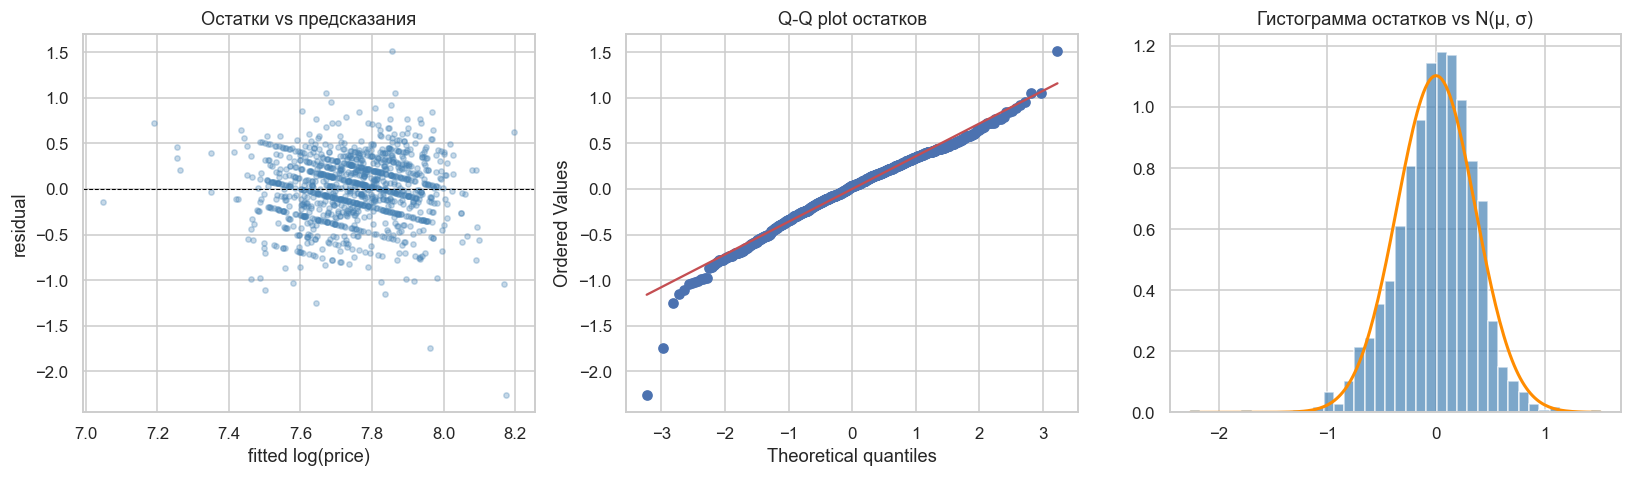

In [10]:
# Визуальная диагностика: остатки vs предсказания (гомоскед.), Q-Q plot (нормальность), гистограмма остатков.
fitted = best.fittedvalues
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(fitted, resid, alpha=0.3, s=12, color="steelblue")
axes[0].axhline(0, color="black", lw=0.7, ls="--")
axes[0].set_xlabel("fitted log(price)")
axes[0].set_ylabel("residual")
axes[0].set_title("Остатки vs предсказания")

stats.probplot(resid, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot остатков")

axes[2].hist(resid, bins=40, density=True, color="steelblue", edgecolor="white", alpha=0.7)
xs = np.linspace(resid.min(), resid.max(), 200)
axes[2].plot(xs, stats.norm.pdf(xs, loc=resid.mean(), scale=resid.std()), color="darkorange", lw=2)
axes[2].set_title("Гистограмма остатков vs N(μ, σ)")

fig.tight_layout()
fig.savefig(f"{ECON_DIR}/residual_diagnostics.png")
plt.show()

In [11]:
# 5.1 Линейность: Ramsey RESET (degree=2 — тестируем добавление квадрата предсказаний).
reset = linear_reset(best, power=[2, 3], use_f=True)
print(f"Ramsey RESET (powers 2,3): F={reset.fvalue:.3f}, p-value={reset.pvalue:.4f}")
print("H0: спецификация корректна (нет нелинейности)")
print("вывод:", "отвергаем — есть пропущенные нелинейности" if reset.pvalue < 0.05 else "не отвергаем — спецификация адекватна")

Ramsey RESET (powers 2,3): F=12.988, p-value=0.0000
H0: спецификация корректна (нет нелинейности)
вывод: отвергаем — есть пропущенные нелинейности


In [12]:
# 5.5 Автокорреляция (формально для кросс-секции не определена — наблюдения независимы; включаем для полноты).
dw = durbin_watson(resid)
print(f"Durbin–Watson = {dw:.3f}  (для кросс-секции ориентир — близко к 2; <1 или >3 — повод задуматься)")

Durbin–Watson = 2.022  (для кросс-секции ориентир — близко к 2; <1 или >3 — повод задуматься)


Cook's D > 4/n (0.0035): 34 наблюдений (3.0%)


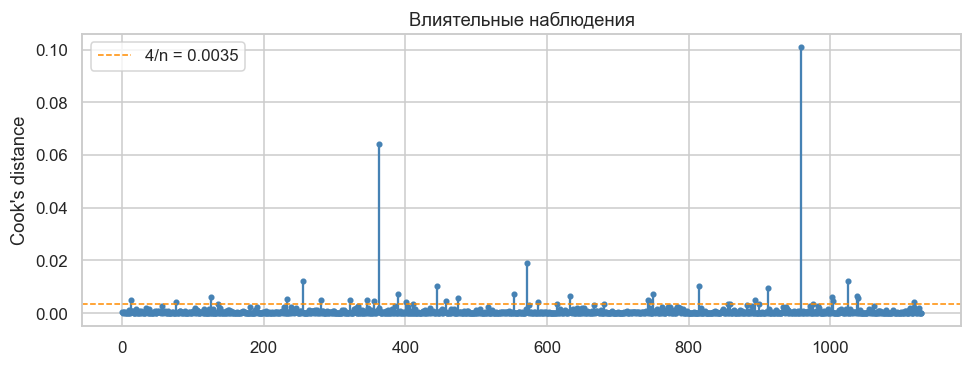

In [13]:
# Влиятельные наблюдения: Cook's distance > 4/n — кандидаты на проверку.
infl = OLSInfluence(best)
cook = infl.cooks_distance[0]
thr = 4 / len(cook)
n_inf = int((cook > thr).sum())
print(f"Cook's D > 4/n ({thr:.4f}): {n_inf} наблюдений ({n_inf/len(cook):.1%})")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.stem(cook, basefmt=" ", markerfmt=".", linefmt="steelblue")
ax.axhline(thr, color="darkorange", lw=1, ls="--", label=f"4/n = {thr:.4f}")
ax.set_ylabel("Cook's distance")
ax.set_title("Влиятельные наблюдения")
ax.legend()
fig.tight_layout()
fig.savefig(f"{ECON_DIR}/cooks_distance.png")
plt.show()

## 6. Робастные стандартные ошибки

Если тесты Breusch–Pagan/White отвергают гомоскедастичность — пересчитаем стандартные ошибки по HC3 (расширение Уайта, лучше для малых выборок). Сравним t-статистики и значимость.

In [14]:
best_robust = best.get_robustcov_results(cov_type="HC3")
comp = pd.DataFrame({
    "coef": best.params,
    "se_OLS": best.bse,
    "t_OLS": best.tvalues,
    "p_OLS": best.pvalues,
    "se_HC3": best_robust.bse,
    "t_HC3": best_robust.tvalues,
    "p_HC3": best_robust.pvalues,
}).round(4)
comp.to_csv(f"{ECON_DIR}/robust_se_comparison.csv")
print(comp)

                 coef  se_OLS   t_OLS  p_OLS  se_HC3   t_HC3  p_HC3
Intercept      5.8549  0.4891 11.9704 0.0000  0.5542 10.5644 0.0000
log_exp        0.0493  0.0141  3.4985 0.0005  0.0141  3.5054 0.0005
log_reviews    0.0868  0.0120  7.2444 0.0000  0.0132  6.5901 0.0000
rating_avg_imp 0.2681  0.0973  2.7550 0.0060  0.1090  2.4586 0.0141
rating_missing 0.0000  0.0000     NaN    NaN  0.0000     NaN    NaN
log_about_len  0.0329  0.0077  4.2633 0.0000  0.0077  4.2791 0.0000
about_missing  0.0000  0.0000     NaN    NaN  0.0000     NaN    NaN


## 7. Тесты значимости коэффициентов и модели в целом

- **F-тест общей значимости:** $H_0: \beta_1 = \beta_2 = \dots = \beta_k = 0$.
- **t-тесты индивидуальной значимости:** $H_0: \beta_j = 0$ — стандартные на HC3.
- **F-тест блока сигнальных переменных** (`is_top_university`, `male`, `female`, `client_visit_available`).
- **F-тест блока количественных характеристик профиля** (`log_education`, `log_achievements`).


In [15]:
print(f"Общий F-тест модели: F = {best.fvalue:.2f}, p = {best.f_pvalue:.2e}")
print(f"  H0: все наклоны = 0  →  {'ОТВЕРГАЕМ' if best.f_pvalue < 0.01 else 'не отвергаем'}")
print()

signal_block = ["is_top_university", "male", "female", "client_visit_available"]
signal_block = [v for v in signal_block if v in best.params.index]
if signal_block:
    f_signal = best.f_test(" = ".join(signal_block) + " = 0")
    print(f"F-тест блока сигналов {signal_block}: F = {float(f_signal.fvalue):.2f}, p = {float(f_signal.pvalue):.4f}")

profile_block = ["log_education", "log_achievements"]
profile_block = [v for v in profile_block if v in best.params.index]
if profile_block:
    f_profile = best.f_test(" = ".join(profile_block) + " = 0")
    print(f"F-тест блока характеристик профиля {profile_block}: F = {float(f_profile.fvalue):.2f}, p = {float(f_profile.pvalue):.4f}")

Общий F-тест модели: F = 43.00, p = 1.32e-33
  H0: все наклоны = 0  →  ОТВЕРГАЕМ



## 8. Проверка устойчивости: длинный файл с фиксированными эффектами по предмету и кластерными ошибками

На длинном файле каждое наблюдение — пара (репетитор, предмет). Это даёт больше степеней свободы для оценки субъект-эффектов; стандартные ошибки кластеризуем по `id` (наблюдения одного репетитора скоррелированы).

In [16]:
df_long = df_long_full.dropna(subset=["subject_price_avg"]).copy()
df_long = df_long[df_long["subject_price_avg"] > 0].copy()

df_long["log_subject_price"]    = np.log(df_long["subject_price_avg"])
df_long["log_exp"]              = np.log1p(df_long["experience_years"].fillna(0))
df_long["log_reviews"]          = np.log1p(df_long["reviews_count"])
df_long["log_about_len"]        = np.log1p(df_long["about_len"])
df_long["log_education"]        = np.log1p(df_long["education_count"])
df_long["log_achievements"]     = np.log1p(df_long["achievements_count"])
df_long["is_top_university"]    = df_long["is_top_university"].astype(int)
df_long["client_visit_available"] = df_long["client_visit_available"].astype(int)
df_long["male"]   = (df_long["gender_raw"] == "MALE").astype(int)
df_long["female"] = (df_long["gender_raw"] == "FEMALE").astype(int)
df_long["rating_missing"] = df_long["rating_avg"].isna().astype(int)
df_long["rating_avg_imp"] = df_long["rating_avg"].fillna(df_long["rating_avg"].median())

formula_long = (
    "log_subject_price ~ log_exp + log_reviews + rating_avg_imp + rating_missing + log_about_len + "
    "is_top_university + client_visit_available + male + female + log_education + log_achievements + "
    "C(subject)"
)
best_long = smf.ols(formula_long, data=df_long).fit(
    cov_type="cluster", cov_kwds={"groups": df_long["id"]}
)
print(best_long.summary())

                            OLS Regression Results                            
Dep. Variable:      log_subject_price   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                 3.538e+04
Date:                Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                        22:55:33   Log-Likelihood:                -929.69
No. Observations:                2092   AIC:                             1887.
Df Residuals:                    2078   BIC:                             1966.
Df Model:                          13                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [17]:
# Сравнение коэффициентов лучшей модели и долговой версии (с фиксированными эффектами).
robust_params = pd.Series(best_robust.params, index=best.model.exog_names)
robust_bse = pd.Series(best_robust.bse, index=best.model.exog_names)
common = [c for c in robust_params.index if c in best_long.params.index]
side_by_side = pd.DataFrame({
    "profile-level (best, HC3)": robust_params.reindex(common),
    "se HC3":                   robust_bse.reindex(common),
    "long+subject FE (cluster)": best_long.params.reindex(common),
    "se cluster":                best_long.bse.reindex(common),
}).round(4)
side_by_side.to_csv(f"{ECON_DIR}/coef_comparison.csv")
side_by_side

                profile-level (best, HC3)  se HC3  long+subject FE (cluster)  se cluster
Intercept                          5.8549  0.5542                     3.7316      0.4498
log_exp                            0.0493  0.0141                     0.0709      0.0169
log_reviews                        0.0868  0.0132                     0.0557      0.0176
rating_avg_imp                     0.2681  0.1090                     0.3080      0.1287
rating_missing                     0.0000  0.0000                    -0.0000      0.0000
log_about_len                      0.0329  0.0077                     0.0300      0.0102

## 9. Выводы

In [18]:
robust_p = pd.Series(best_robust.pvalues, index=best.model.exog_names)
robust_b = pd.Series(best_robust.params,  index=best.model.exog_names)

lines = []
lines.append(f"Выборка: {len(df)} активных репетиторов ЕГЭ с указанной ценой.")
lines.append("")
lines.append(f"ВЫБОР ФУНКЦИОНАЛЬНОЙ ФОРМЫ")
lines.append(f"  • Лог-преобразование цены приводит асимметрию с {df_full['price_avg'].skew():.2f} к ≈0,")
lines.append(f"    поэтому используем log(price) как зависимую переменную.")
lines.append(f"  • Лог–лог спецификация даёт интерпретируемые эластичности по непрерывным регрессорам.")
lines.append("")
lines.append(f"СРАВНЕНИЕ МОДЕЛЕЙ (по log_price, n={int(best.nobs)}):")
for name, res in log_models.items():
    star = " ← BEST" if name == best_name else ""
    lines.append(f"  • {name:30s} Adj R²={res.rsquared_adj:.3f}  AIC={res.aic:.1f}  BIC={res.bic:.1f}{star}")
lines.append("")
lines.append(f"ПРЕДПОСЫЛКИ ГАУССА–МАРКОВА (для модели {best_name}):")
lines.append(f"  1. Линейность по параметрам — выполнена по построению; Ramsey RESET p={reset.pvalue:.3f}.")
max_vif = vif.loc[vif['переменная']!='Intercept', 'VIF'].max()
lines.append(f"  2. Мультиколлинеарность: max VIF = {max_vif:.2f} → {'ПРОБЛЕМА' if max_vif > 10 else 'нет проблемы'}.")
lines.append(f"  3. Гомоскедастичность: Breusch–Pagan p={bp_lm_p:.2e}, White p={wh_lm_p:.2e} →")
lines.append(f"     {'ОТВЕРГНУТА — используем HC3 робастные ошибки' if (bp_lm_p < 0.05 or wh_lm_p < 0.05) else 'не отвергнута'}.")
lines.append(f"  4. Автокорреляция: Durbin–Watson = {dw:.2f} (для кросс-секции не критично).")
lines.append(f"  5. Нормальность остатков: Jarque–Bera p={jb_p:.2e}, Anderson–Darling p={ad_p:.2e} →")
lines.append(f"     {'отвергнута' if jb_p < 0.05 else 'не отвергнута'} (но при n={int(best.nobs)} ЦПТ обеспечивает асимптотическую корректность тестов).")
lines.append("")
lines.append(f"ЗНАЧИМОСТЬ:")
lines.append(f"  • Общий F-тест: F={best.fvalue:.1f}, p={best.f_pvalue:.2e} — модель в целом значима.")
sig_names = list(robust_p[robust_p < 0.05].index)
lines.append(f"  • Индивидуально значимы (HC3, p<0.05): {sig_names}")
lines.append("")
lines.append(f"КЛЮЧЕВЫЕ ЭКОНОМИЧЕСКИЕ ВЫВОДЫ (модель {best_name}, HC3):")
interp = {
    "log_exp":                "эластичность цены по опыту (≈% при росте опыта на 1%)",
    "log_reviews":            "эластичность цены по числу отзывов (≈% при росте отзывов на 1%)",
    "log_about_len":          "эластичность цены по длине описания",
    "log_education":          "эластичность цены по числу образовательных записей",
    "log_achievements":       "эластичность цены по числу достижений",
    "is_top_university":      "премия за топ-вуз",
    "client_visit_available": "премия за выезд к ученику",
    "male":                   "гендерная разница (мужчины vs пропуск)",
    "female":                 "гендерная разница (женщины vs пропуск)",
    "rating_avg_imp":         "полу-эластичность по рейтингу (β·100% за +1 балл)",
}
for var, descr in interp.items():
    if var in robust_b.index:
        b = robust_b[var]; p = robust_p[var]
        sigchar = "*" if p < 0.05 else " "
        if var.startswith("log_"):
            lines.append(f"  {sigchar} {var:25s} β={b:+.3f}  p={p:.3f}  → {descr}: {b*100:+.1f}%.")
        elif var == "rating_avg_imp":
            lines.append(f"  {sigchar} {var:25s} β={b:+.3f}  p={p:.3f}  → {descr}: {b*100:+.1f}% за +1 балл.")
        else:
            lines.append(f"  {sigchar} {var:25s} β={b:+.3f}  p={p:.3f}  → {descr}: {(np.exp(b)-1)*100:+.1f}%.")

memo = "\n".join(lines)
print(memo)
with open(f"{ECON_DIR}/conclusions.txt", "w") as f:
    f.write(memo)

Выборка: 1130 активных репетиторов ЕГЭ с указанной ценой.

ВЫБОР ФУНКЦИОНАЛЬНОЙ ФОРМЫ
  • Лог-преобразование цены приводит асимметрию с 1.61 к ≈0,
    поэтому используем log(price) как зависимую переменную.
  • Лог–лог спецификация даёт интерпретируемые эластичности по непрерывным регрессорам.

СРАВНЕНИЕ МОДЕЛЕЙ (по log_price, n=1130):
  • M2 (log-linear)                Adj R²=0.048  AIC=1019.2  BIC=1039.3
  • M3 (log-log)                   Adj R²=0.130  AIC=918.6  BIC=943.7 ← BEST
  • M4 (log-log + dummies)         Adj R²=0.132  AIC=920.1  BIC=970.4
  • M5 (M4 + interaction)          Adj R²=0.132  AIC=921.8  BIC=977.1

ПРЕДПОСЫЛКИ ГАУССА–МАРКОВА (для модели M3 (log-log)):
  1. Линейность по параметрам — выполнена по построению; Ramsey RESET p=0.000.
  2. Мультиколлинеарность: max VIF = 1.69 → нет проблемы.
  3. Гомоскедастичность: Breusch–Pagan p=2.55e-02, White p=1.12e-08 →
     ОТВЕРГНУТА — используем HC3 робастные ошибки.
  4. Автокорреляция: Durbin–Watson = 2.02 (для кросс-секции 